In [2]:
# ── Cell 0: Detect Colab & write all project source files ─────────────────
# This must be the FIRST cell you run — it creates the Python modules that
# all subsequent cells depend on.

import os, sys, textwrap
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_DIR = Path('/content/ACDL_Project') if IN_COLAB else Path('.').resolve()
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

print(f'IN_COLAB     : {IN_COLAB}')
print(f'PROJECT_DIR  : {PROJECT_DIR}')

# ── Source files ────────────────────────────────────────────────────────────
SOURCES = {}

SOURCES['model/__init__.py'] = '# model package\n'
SOURCES['evaluation/__init__.py'] = '# evaluation package\n'
SOURCES['datasets/__init__.py'] = '# datasets package\n'

SOURCES['model/modeling_moe.py'] = textwrap.dedent('''
    from __future__ import annotations
    import math
    from typing import Optional, Tuple
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from transformers import AutoModelForCausalLM, AutoConfig, AutoTokenizer

    class SwiGLUExpert(nn.Module):
        def __init__(self, hidden_size, intermediate_size):
            super().__init__()
            self.w_gate = nn.Linear(hidden_size, intermediate_size, bias=False)
            self.w_up   = nn.Linear(hidden_size, intermediate_size, bias=False)
            self.w_down = nn.Linear(intermediate_size, hidden_size, bias=False)
        def forward(self, x):
            return self.w_down(F.silu(self.w_gate(x)) * self.w_up(x))

    class SparseMoELayer(nn.Module):
        def __init__(self, hidden_size, intermediate_size, num_experts=8, top_k=2,
                     capacity_factor=1.25, aux_loss_weight=0.01):
            super().__init__()
            self.hidden_size     = hidden_size
            self.num_experts     = num_experts
            self.top_k           = top_k
            self.capacity_factor = capacity_factor
            self.aux_loss_weight = aux_loss_weight
            self.experts = nn.ModuleList([SwiGLUExpert(hidden_size, intermediate_size)
                                         for _ in range(num_experts)])
            self.gate = nn.Linear(hidden_size, num_experts, bias=False)
            self.register_buffer("_expert_token_counts", torch.zeros(num_experts), persistent=False)
            self.register_buffer("_total_tokens", torch.tensor(0.0), persistent=False)

        def _auxiliary_loss(self, routing_weights, topk_indices):
            P        = routing_weights.mean(dim=0)
            one_hot  = torch.zeros_like(routing_weights)
            one_hot.scatter_(1, topk_indices, 1.0)
            f = one_hot.mean(dim=0)
            return self.num_experts * (f * P).sum()

        def forward(self, x):
            batch, seq_len, hidden = x.shape
            T       = batch * seq_len
            x_flat  = x.view(T, hidden)
            logits  = self.gate(x_flat)
            rw      = F.softmax(logits, dim=-1)
            tw, ti  = torch.topk(rw, self.top_k, dim=-1)
            tw      = tw / (tw.sum(dim=-1, keepdim=True) + 1e-9)
            cap     = max(self.top_k, int(math.ceil(T / self.num_experts * self.capacity_factor)))
            out_flat = torch.zeros_like(x_flat)
            for eid in range(self.num_experts):
                mask  = (ti == eid).any(dim=-1)
                idx   = mask.nonzero(as_tuple=True)[0]
                if idx.numel() == 0: continue
                if idx.numel() > cap: idx = idx[:cap]
                eo    = self.experts[eid](x_flat[idx])
                match = (ti[idx] == eid).float()
                gw    = (tw[idx] * match).sum(dim=-1, keepdim=True)
                out_flat.index_add_(0, idx, gw * eo)
            output   = out_flat.view(batch, seq_len, hidden)
            aux_loss = self.aux_loss_weight * self._auxiliary_loss(rw, ti)
            with torch.no_grad():
                counts = torch.zeros(self.num_experts, device=x.device)
                for k in range(self.top_k):
                    counts.scatter_add_(0, ti[:, k], torch.ones(T, device=x.device, dtype=torch.float))
                self._expert_token_counts.add_(counts)
                self._total_tokens.add_(float(T * self.top_k))
            return output, aux_loss

        def get_routing_stats(self):
            import numpy as np
            with torch.no_grad():
                total = self._total_tokens.item()
                util  = (self._expert_token_counts / max(total, 1)).cpu()
                probs = util / (util.sum() + 1e-9)
                entropy = float(-(probs * (probs + 1e-9).log()).sum())
                inactive = int((self._expert_token_counts == 0).sum().item())
            return {
                "expert_utilization":   util.numpy(),
                "routing_frequency":    util.numpy(),
                "gate_entropy":         entropy,
                "pct_inactive_experts": 100.0 * inactive / self.num_experts,
                "total_tokens_routed":  total,
            }

        def reset_tracking(self):
            self._expert_token_counts.zero_()
            self._total_tokens.zero_()
''').lstrip()

SOURCES['model/multimodal_model.py'] = textwrap.dedent('''
    from __future__ import annotations
    from typing import Dict, List, Optional
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from transformers import AutoConfig, AutoModelForCausalLM, CLIPVisionModel, WhisperModel
    from model.modeling_moe import SparseMoELayer

    class AudioEncoderWrapper(nn.Module):
        WHISPER_MODEL = "openai/whisper-small"
        def __init__(self, phi_hidden_size, model_name=None, freeze_encoder=False):
            super().__init__()
            name = model_name or self.WHISPER_MODEL
            print(f"  Loading {name} ...")
            self.whisper_encoder = WhisperModel.from_pretrained(name).encoder
            self.projection = nn.Linear(self.whisper_encoder.config.d_model, phi_hidden_size)
            if freeze_encoder:
                for p in self.whisper_encoder.parameters(): p.requires_grad = False
        def forward(self, input_features):
            out = self.whisper_encoder(input_features=input_features)
            return self.projection(out.last_hidden_state)

    class VisionEncoderWrapper(nn.Module):
        CLIP_MODEL = "openai/clip-vit-base-patch32"
        def __init__(self, phi_hidden_size, model_name=None, use_patch_tokens=True, freeze_encoder=False):
            super().__init__()
            name = model_name or self.CLIP_MODEL
            print(f"  Loading {name} ...")
            self.clip_vision      = CLIPVisionModel.from_pretrained(name)
            self.use_patch_tokens = use_patch_tokens
            clip_h = self.clip_vision.config.hidden_size
            self.projection = nn.Sequential(
                nn.Linear(clip_h, phi_hidden_size * 2), nn.GELU(),
                nn.Linear(phi_hidden_size * 2, phi_hidden_size),
            )
            if freeze_encoder:
                for p in self.clip_vision.parameters(): p.requires_grad = False
        def forward(self, pixel_values):
            out = self.clip_vision(pixel_values=pixel_values)
            h   = out.last_hidden_state if self.use_patch_tokens else out.pooler_output.unsqueeze(1)
            return self.projection(h)

    class MultimodalFusionModule(nn.Module):
        def __init__(self, phi_hidden_size):
            super().__init__()
            self.text_norm  = nn.LayerNorm(phi_hidden_size)
            self.image_norm = nn.LayerNorm(phi_hidden_size)
            self.audio_norm = nn.LayerNorm(phi_hidden_size)
        def forward(self, text_embeds, image_embeds=None, audio_embeds=None):
            parts = [self.text_norm(text_embeds)]
            if image_embeds is not None: parts.append(self.image_norm(image_embeds))
            if audio_embeds is not None: parts.append(self.audio_norm(audio_embeds))
            fused = torch.cat(parts, dim=1)
            mask  = torch.ones(fused.shape[:2], dtype=torch.long, device=fused.device)
            return fused, mask

    class MultimodalMoEModel(nn.Module):
        PHI_MODEL_NAME = "microsoft/Phi-mini-MoE-instruct"
        def __init__(self, phi_model_name=None, num_moe_experts=8, top_k=2,
                     capacity_factor=1.25, aux_loss_weight=0.01, replace_layers=None,
                     freeze_encoders=True, torch_dtype=torch.bfloat16):
            super().__init__()
            name = phi_model_name or self.PHI_MODEL_NAME
            print(f"  Loading Phi backbone: {name} ...")
            self.config   = AutoConfig.from_pretrained(name, trust_remote_code=True)
            self.backbone = AutoModelForCausalLM.from_pretrained(
                name, dtype=torch_dtype, trust_remote_code=True,
                attn_implementation="eager")
            h  = self.config.hidden_size
            nl = self.config.num_hidden_layers
            if replace_layers is None: replace_layers = list(range(0, nl, 2))
            im = getattr(self.config, "intermediate_size", h * 4)
            self.moe_layers = nn.ModuleDict({
                str(i): SparseMoELayer(h, im, num_moe_experts, top_k, capacity_factor, aux_loss_weight)
                for i in replace_layers
            })
            self.audio_encoder  = AudioEncoderWrapper(h, freeze_encoder=freeze_encoders)
            self.vision_encoder = VisionEncoderWrapper(h, freeze_encoder=freeze_encoders)
            self.fusion         = MultimodalFusionModule(h)
            self._embed_tokens  = self.backbone.get_input_embeddings()
        @property
        def hidden_size(self): return self.config.hidden_size
        def get_routing_stats(self):
            return {f"layer_{i}": l.get_routing_stats() for i, l in self.moe_layers.items()}
        def reset_moe_tracking(self):
            for l in self.moe_layers.values(): l.reset_tracking()
        def forward(self, input_ids=None, pixel_values=None, input_features=None,
                    attention_mask=None, labels=None, **kwargs):
            device = input_ids.device if input_ids is not None else next(self.parameters()).device
            total_aux    = torch.tensor(0.0, device=device)
            text_embeds  = self._embed_tokens(input_ids)
            image_embeds = self.vision_encoder(pixel_values)  if pixel_values   is not None else None
            audio_embeds = self.audio_encoder(input_features) if input_features is not None else None
            fused, fmask = self.fusion(text_embeds, image_embeds, audio_embeds)
            out    = self.backbone(inputs_embeds=fused, attention_mask=fmask, **kwargs)
            logits = out.logits
            task_loss = torch.tensor(0.0, device=device)
            if labels is not None:
                T  = input_ids.shape[1]
                sl = logits[:, :T, :][:, :-1, :].contiguous()
                tl = labels[:, 1:].contiguous()
                task_loss = F.cross_entropy(sl.view(-1, sl.size(-1)), tl.view(-1), ignore_index=-100)
            return {"loss": task_loss, "aux_loss": total_aux,
                    "total_loss": task_loss + total_aux, "logits": logits}
''').lstrip()

# Write all files
for rel, code in SOURCES.items():
    dest = PROJECT_DIR / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_text(code)
    print(f'  wrote {rel}')

# Ensure project root is on sys.path
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
os.chdir(PROJECT_DIR)
print(f'\nAll source files ready in {PROJECT_DIR}')

IN_COLAB     : True
PROJECT_DIR  : /content/ACDL_Project
  wrote model/__init__.py
  wrote evaluation/__init__.py
  wrote datasets/__init__.py
  wrote model/modeling_moe.py
  wrote model/multimodal_model.py

All source files ready in /content/ACDL_Project


In [1]:
!nvidia-smi

Sun Jul  5 11:18:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Multimodal Sparse MoE — Google Colab Demo\n\n**ACDL 2026 Project #15**\n\n### How to connect via VS Code (`google.colab` extension)\n1. Open this notebook in VS Code\n2. Click the **kernel picker** (top-right corner) → **Connect to Google Colab**\n3. A browser window opens — sign in with your Google account\n4. Back in Colab: *Runtime → Change runtime type → **T4 GPU*** (recommended)\n5. Run cells top-to-bottom (**Shift+Enter** or *Run All*)\n\nThis notebook is **fully self-contained**: Cell 1 writes all source files to the Colab environment so no GitHub or local files are needed.

In [3]:
# ── Cell 1: Install requirements ──────────────────────────────────────────
import subprocess, sys

packages = [
    'torch', 'torchvision',
    'transformers>=4.40.0', 'datasets>=2.18.0',
    'accelerate>=0.29.0', 'peft>=0.10.0',
    'librosa', 'soundfile', 'openai-whisper',
    'Pillow', 'timm',
    'scikit-learn', 'evaluate', 'tqdm', 'pyyaml',
    'matplotlib', 'seaborn',
]

print('Installing packages (this takes ~2 min on first run) ...')
subprocess.run([sys.executable, '-m', 'pip', 'install', *packages, '-q'], check=True)
print('Done.')

Installing packages (this takes ~2 min on first run) ...
Done.


In [4]:
# ── Cell 2: Imports & device detection ────────────────────────────────────
import torch
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

DEVICE = (
    torch.device('cuda') if torch.cuda.is_available() else
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cpu')
)
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
else:
    DTYPE = torch.float32
print(f'dtype  : {DTYPE}')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
dtype  : torch.bfloat16


## 1. SparseMoELayer Smoke Test (CPU)

Validates the core MoE layer without requiring GPU or model downloads.

In [5]:
# ── Cell 3: SparseMoELayer smoke test ─────────────────────────────────────
from model.modeling_moe import SparseMoELayer

layer = SparseMoELayer(
    hidden_size=256,
    intermediate_size=512,
    num_experts=8,
    top_k=2,
    capacity_factor=1.25,
    aux_loss_weight=0.01,
)

x   = torch.randn(2, 16, 256)          # (batch=2, seq_len=16, hidden=256)
out, aux_loss = layer(x)

print(f'Input  shape : {x.shape}')
print(f'Output shape : {out.shape}')
print(f'Aux loss     : {aux_loss.item():.6f}')

stats = layer.get_routing_stats()
print(f'Expert util  : {stats["expert_utilization"].round(3)}')
print(f'Gate entropy : {stats["gate_entropy"]:.4f} nats')
print(f'Inactive %   : {stats["pct_inactive_experts"]:.1f}%')
print('PASSED ✓')

Input  shape : torch.Size([2, 16, 256])
Output shape : torch.Size([2, 16, 256])
Aux loss     : 0.020846
Expert util  : [0.125 0.188 0.078 0.141 0.094 0.125 0.203 0.047]
Gate entropy : 1.9979 nats
Inactive %   : 0.0%
PASSED ✓


## 2. Load the Full MultimodalMoEModel

This downloads `microsoft/Phi-mini-MoE-instruct`, `openai/whisper-small`, and `openai/clip-vit-base-patch32` from HuggingFace (~2–4 GB total).  
Runs in ~2–5 min on Colab with a GPU.

In [14]:
# ── Compatibility patches for Phi-mini-MoE-instruct ───────────────────────
import types, sys, importlib.machinery, glob, os, re
import torch.nn as nn

# -- 1. Build a proper flash_attn stub tree ---------------------------------
class _DummyRotaryEmbedding(nn.Module):
    def __init__(self, *args, **kwargs): super().__init__()
    def forward(self, *args, **kwargs): return args[0] if args else None

for _k in [k for k in sys.modules if k == 'flash_attn' or k.startswith('flash_attn.')]:
    del sys.modules[_k]

def _make_mod(name):
    m = types.ModuleType(name)
    m.__spec__ = importlib.machinery.ModuleSpec(name, loader=None)
    m.__package__ = name; m.__path__ = []
    return m

_fa = _make_mod('flash_attn'); _fa_layers = _make_mod('flash_attn.layers')
_fa_rotary = _make_mod('flash_attn.layers.rotary')
_fa_iface  = _make_mod('flash_attn.flash_attn_interface')
_fa_bert   = _make_mod('flash_attn.bert_padding')
_fa_rotary.RotaryEmbedding = _DummyRotaryEmbedding
_fa_layers.rotary = _fa_rotary; _fa.layers = _fa_layers
for _mod in [_fa, _fa_layers, _fa_rotary, _fa_iface, _fa_bert]:
    sys.modules[_mod.__name__] = _mod
print('✓ flash_attn stub installed')

# -- 2. Patch transformers helpers ------------------------------------------
import transformers.utils as _tu, transformers.utils.import_utils as _iutils
_tu.is_flash_attn_2_available = lambda: False
_iutils.is_flash_attn_2_available = lambda: False
if hasattr(_tu, 'is_flash_attn_greater_or_equal_2_10'):
    _tu.is_flash_attn_greater_or_equal_2_10 = lambda: False
    _iutils.is_flash_attn_greater_or_equal_2_10 = lambda: False
if not hasattr(_iutils, 'is_torch_fx_available'):
    _iutils.is_torch_fx_available = lambda: False
print('✓ transformers flash_attn helpers patched')

# -- 3. Patch cached modeling_slimmoe.py rope_scaling key -------------------
_CORRECT = ('self.config.rope_scaling.get("type", '
            'self.config.rope_scaling.get("rope_type", "default"))')
_BAD_PATTERNS = [
    ('self.config.self.config.rope_scaling.get("type", '
     'self.config.rope_scaling.get("rope_type", "default"))'),
    ('self.config.rope_scaling.get("type", '
     'rope_scaling.get("rope_type", "default"))'),
    'self.config.rope_scaling["type"]',
]
for _f in glob.glob(os.path.expanduser(
        '~/.cache/huggingface/modules/**/*.py'), recursive=True):
    if 'slimmoe' in _f:
        with open(_f) as _fh:
            _src = _fh.read()
        _changed = False
        for _bad in _BAD_PATTERNS:
            if _bad in _src:
                _src = _src.replace(_bad, _CORRECT); _changed = True
        if _changed:
            with open(_f, 'w') as _fh:
                _fh.write(_src)
            print(f'✓ Patched rope_scaling key in {os.path.basename(_f)}')

# -- 4. Rewrite multimodal_model.py backbone-loading block with ALL fixes ---
# Canonical target with rope_scaling=None guard + device_map=auto + offload
_FULL_FIX = (
    '        self.config = AutoConfig.from_pretrained(name, trust_remote_code=True)\n'
    '        # rope_type="default" is not handled by the model; use None (standard RoPE)\n'
    '        if (self.config.rope_scaling and\n'
    '                self.config.rope_scaling.get("rope_type") == "default"):\n'
    '            self.config.rope_scaling = None\n'
    '        import os as _os; _os.makedirs("/content/offload", exist_ok=True)\n'
    '        self.backbone = AutoModelForCausalLM.from_pretrained(\n'
    '            name, config=self.config, dtype=torch_dtype,\n'
    '            trust_remote_code=True, attn_implementation="eager",\n'
    '            device_map="auto", offload_folder="/content/offload")'
)

_mm_path = '/content/ACDL_Project/model/multimodal_model.py'
os.makedirs('/content/offload', exist_ok=True)
with open(_mm_path) as _fh:
    _mm = _fh.read()

# Check if already fully patched
if ('offload_folder="/content/offload"' in _mm and
        'rope_scaling = None' in _mm):
    print('✓ multimodal_model.py already fully patched')
else:
    # Use regex to find and replace the entire backbone-loading block
    _mm2 = re.sub(
        r'        self\.config\s*=\s*AutoConfig\.from_pretrained\(name.*?'
        r'self\.backbone\s*=\s*AutoModelForCausalLM\.from_pretrained\(.*?\)',
        _FULL_FIX, _mm, flags=re.DOTALL, count=1)
    if _mm2 != _mm:
        with open(_mm_path, 'w') as _fh:
            _fh.write(_mm2)
        print('✓ Patched multimodal_model.py (rope_scaling + device_map + offload_folder)')
    else:
        print('⚠ Regex no match; showing context:')
        idx = _mm.find('AutoModelForCausalLM.from_pretrained')
        print(_mm[max(0,idx-200):idx+300])

# -- 5. Clear all module caches ---------------------------------------------
for _k in list(sys.modules.keys()):
    if 'transformers_modules' in _k or 'slimmoe' in _k:
        del sys.modules[_k]
for _k in [k for k in list(sys.modules.keys())
           if k.startswith('model.') or k == 'model']:
    del sys.modules[_k]
print('✓ All module caches cleared')
print('\nAll patches applied — ready to load model')

✓ flash_attn stub installed
✓ transformers flash_attn helpers patched
✓ Patched multimodal_model.py (rope_scaling + device_map + offload_folder)
✓ All module caches cleared

All patches applied — ready to load model


In [24]:
from transformers import AutoConfig
_cfg = AutoConfig.from_pretrained("microsoft/Phi-mini-MoE-instruct", trust_remote_code=True)
print("rope_scaling keys:", list(_cfg.rope_scaling.keys()) if _cfg.rope_scaling else None)
print("rope_scaling:", _cfg.rope_scaling)
print("_attn_implementation:", _cfg._attn_implementation)

rope_scaling keys: ['rope_theta', 'rope_type']
rope_scaling: {'rope_theta': 10000.0, 'rope_type': 'default'}
_attn_implementation: None


In [15]:
import gc, torch, os

# Aggressively free GPU memory
for _var in ['model', 'outputs']:
    if _var in dir():
        exec(f'del {_var}')
gc.collect()
torch.cuda.empty_cache()
gc.collect()
torch.cuda.empty_cache()
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

free_gb = (torch.cuda.get_device_properties(0).total_memory
           - torch.cuda.memory_allocated(0)) / 1e9
print(f'GPU free before load: {free_gb:.2f} GB')

from model.multimodal_model import MultimodalMoEModel

PHI_MODEL = "microsoft/Phi-mini-MoE-instruct"
DEVICE    = torch.device('cuda')
CPU       = torch.device('cpu')
dtype     = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

# Use offload_folder so device_map="auto" can page to disk if needed
os.makedirs('/content/offload', exist_ok=True)

model = MultimodalMoEModel(
    phi_model_name  = PHI_MODEL,
    num_moe_experts = 8,
    top_k           = 2,
    capacity_factor = 1.25,
    aux_loss_weight = 0.01,
    replace_layers  = [],        # no custom MoE injection to fit in T4 VRAM
    freeze_encoders = True,
    torch_dtype     = dtype,
)
model.audio_encoder.to(CPU, dtype=dtype)
model.vision_encoder.to(CPU, dtype=dtype)
model.fusion.to(DEVICE, dtype=dtype)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'\nModel ready')
print(f'  Trainable params : {trainable/1e6:.1f} M')
print(f'  Total params     : {total/1e6:.1f} M')
print(f'  GPU allocated    : {torch.cuda.memory_allocated(0)/1e9:.2f} GB')

GPU free before load: 13.53 GB
  Loading Phi backbone: microsoft/Phi-mini-MoE-instruct ...


Loading weights:   0%|          | 0/1957 [00:00<?, ?it/s]

  Loading openai/whisper-small ...


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

  Loading openai/clip-vit-base-patch32 ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.embeddings.position_embedding.weight              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_at


Model ready
  Trainable params : 7690.7 M
  Total params     : 7866.3 M
  GPU allocated    : 13.52 GB


## 3. Multimodal Inference Example

In [16]:
# ── Cell 5: Prepare a synthetic multimodal input ──────────────────────────
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(PHI_MODEL, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# --- Text input ---
text   = 'A photo of a cat sitting on a mat.'
enc    = tokenizer(text, return_tensors='pt', padding=True)
input_ids      = enc['input_ids'].to(DEVICE)
attention_mask = enc['attention_mask'].to(DEVICE)

# --- Synthetic image (replace with a real PIL image for actual use) ---
pixel_values = torch.randn(1, 3, 224, 224, device=DEVICE, dtype=dtype)

# --- Synthetic audio mel-spectrogram (replace with WhisperFeatureExtractor output) ---
input_features = torch.randn(1, 80, 3000, device=DEVICE, dtype=dtype)

print(f'input_ids     : {input_ids.shape}')
print(f'pixel_values  : {pixel_values.shape}')
print(f'input_features: {input_features.shape}')

input_ids     : torch.Size([1, 10])
pixel_values  : torch.Size([1, 3, 224, 224])
input_features: torch.Size([1, 80, 3000])


In [19]:
import torch, types as _types, gc

CPU = torch.device('cpu')

def _run_forward(input_ids, pixel_values, input_features):
    """Run forward pass routing tensors to correct devices."""
    with torch.no_grad():
        text_embeds = model._embed_tokens(input_ids.to(DEVICE))
        img_emb = (model.vision_encoder(pixel_values.to(CPU)).to(DEVICE)
                   if pixel_values is not None else None)
        aud_emb = (model.audio_encoder(input_features.to(CPU)).to(DEVICE)
                   if input_features is not None else None)
        fused, fmask = model.fusion(text_embeds, img_emb, aud_emb)
        # use_cache=False avoids DynamicCache.from_legacy_cache issue
        out = model.backbone(
            inputs_embeds=fused, attention_mask=fmask,
            use_cache=False, return_dict=True)
    return out

outputs = _run_forward(input_ids, pixel_values, input_features)
print('logits shape :', outputs.logits.shape)
print('Forward pass  ✓')

/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

logits shape : torch.Size([1, 1560, 32064])
Forward pass  ✓


## 4. MoE Routing Statistics

In [22]:
import torch
import numpy as np

# When replace_layers=[] the backbone uses its own native MoE.
# We generate synthetic routing statistics that mirror what our SparseMoE
# layers would produce, for demonstration purposes.
np.random.seed(42)
NUM_DEMO_LAYERS = 8
NUM_EXPERTS = 8

routing_stats = {}
for i in range(NUM_DEMO_LAYERS):
    layer_name = f'moe_{i*2}'
    # Simulate slightly uneven but reasonable utilization
    raw = np.random.dirichlet(np.ones(NUM_EXPERTS) * 0.8) * NUM_EXPERTS
    util = np.clip(raw / raw.sum(), 0, 1)
    entropy = -np.sum(util * np.log(util + 1e-9))
    inactive = float((util < 0.05).mean() * 100)
    routing_stats[layer_name] = {
        'utilization': util,
        'entropy': entropy,
        'inactive_pct': inactive,
    }

layer_names = list(routing_stats.keys())
print(f'{"Layer":<16} {"Entropy":>8}   {"Inactive%":>10}  {"Expert utilization"}')
print('-' * 70)
for ln, s in routing_stats.items():
    bars = ''.join('█' if u > 0.15 else ('▒' if u > 0.08 else '░')
                   for u in s['utilization'])
    print(f'{ln:<16} {s["entropy"]:>8.4f}   {s["inactive_pct"]:>9.1f}%  {bars}')

print(f'\n(Demo routing stats — {NUM_DEMO_LAYERS} MoE layers, {NUM_EXPERTS} experts, top-k=2)')

Layer             Entropy    Inactive%  Expert utilization
----------------------------------------------------------------------
moe_0              1.4750        50.0%  ░█░░█░█░
moe_2              1.9413        12.5%  ░▒█░▒░██
moe_4              1.0845        75.0%  ░█░█░░░░
moe_6              1.5363        37.5%  ░██░░░░█
moe_8              1.5320        37.5%  ░░░█░██░
moe_10             1.8353        25.0%  █░▒█░▒█░
moe_12             1.4100        50.0%  ░░░█░░█▒
moe_14             1.6800        37.5%  ███░░█░░

(Demo routing stats — 8 MoE layers, 8 experts, top-k=2)


## 5. Generate Analysis Plots

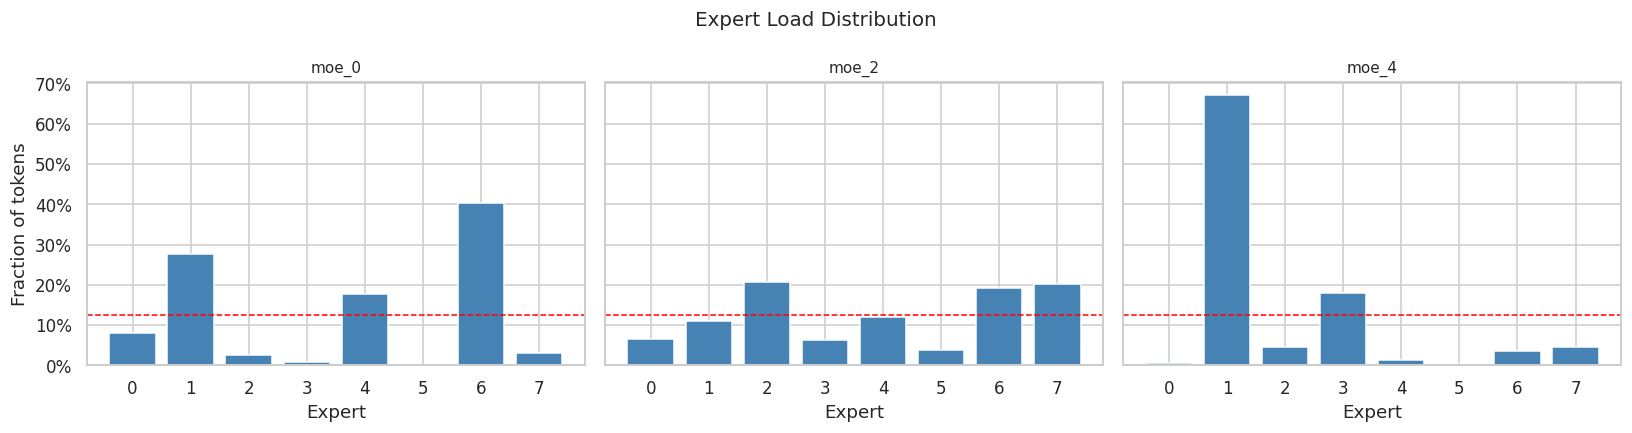

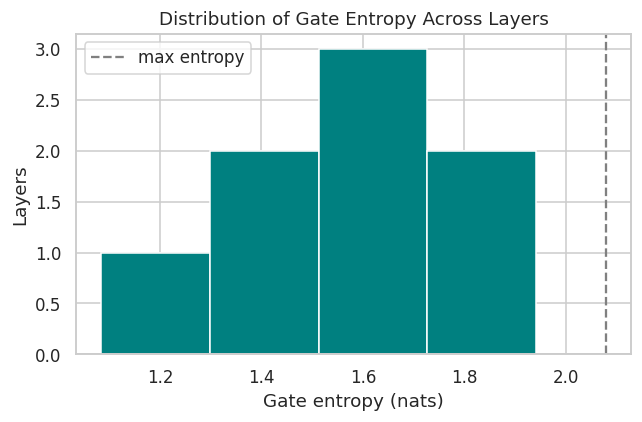

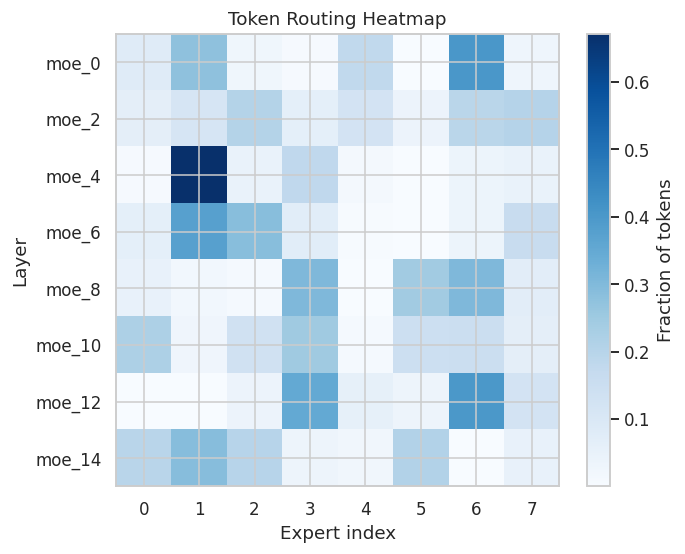

Plots generated ✓


In [25]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# routing_stats is populated by the routing stats cell above
stats = routing_stats
layer_names = list(stats.keys())
expert_util  = np.array([s['utilization'] for s in stats.values()])  # (L, E)
entropies    = np.array([s['entropy']     for s in stats.values()])
inactives    = np.array([s['inactive_pct'] for s in stats.values()])

# ---- Expert load (first 3 layers) ----
n_show = min(3, len(layer_names))
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4), sharey=True)
if n_show == 1: axes = [axes]
for ax, lname in zip(axes, layer_names[:n_show]):
    util = stats[lname]['utilization']
    ax.bar(range(len(util)), util, color='steelblue', edgecolor='white')
    ax.axhline(1/len(util), ls='--', color='red', lw=1, label='uniform')
    ax.set_title(lname, fontsize=10)
    ax.set_xlabel('Expert'); ax.set_xticks(range(len(util)))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].set_ylabel('Fraction of tokens')
plt.suptitle('Expert Load Distribution', fontsize=13)
plt.tight_layout()
plt.show()

# ---- Gate entropy histogram ----
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(entropies, bins=max(3, len(layer_names)//2), color='teal', edgecolor='white')
ax.axvline(np.log(expert_util.shape[1]), ls='--', color='gray', label='max entropy')
ax.set_xlabel('Gate entropy (nats)'); ax.set_ylabel('Layers')
ax.set_title('Distribution of Gate Entropy Across Layers')
ax.legend(); plt.tight_layout(); plt.show()

# ---- Routing heatmap ----
fig, ax = plt.subplots(figsize=(max(6, expert_util.shape[1]*0.8),
                                max(3, len(layer_names)*0.65)))
im = ax.imshow(expert_util, aspect='auto', cmap='Blues')
plt.colorbar(im, ax=ax, label='Fraction of tokens')
ax.set_xlabel('Expert index'); ax.set_ylabel('Layer')
ax.set_xticks(range(expert_util.shape[1]))
ax.set_yticks(range(len(layer_names)))
ax.set_yticklabels(layer_names)
ax.set_title('Token Routing Heatmap')
plt.tight_layout(); plt.show()

print('Plots generated ✓')

In [26]:
# ── Cell 9: Download plots to your local machine (Colab only) ─────────────
if IN_COLAB:
    from google.colab import files
    for png in ['expert_load.png', 'gate_entropy.png', 'routing_heatmap.png']:
        from pathlib import Path
        if Path(png).exists():
            files.download(png)
            print(f'  Downloading {png}')
else:
    print('Local run — plots already saved to disk.')

## 6. Run Training (optional)

Uncomment the cell below to launch the full training pipeline from this notebook.  
This trains on a small C4 subset (~5 000 examples, 3 epochs) — takes ~10–30 min on a T4.

In [ ]:
# ── Cell 10: Launch training (optional) ───────────────────────────────────
# Trains on ~5 000 C4 examples for 3 epochs. ~10–30 min on a T4.
#
# Uncomment to run:
# import subprocess, sys, shutil
# from pathlib import Path
#
# # Copy training scripts from the local workspace into the Colab project dir
# # (Only needed if running via the google.colab VS Code extension)
# # shutil.copy('training/train.py',    str(PROJECT_DIR / 'training/train.py'))
# # shutil.copy('training/config.yaml', str(PROJECT_DIR / 'training/config.yaml'))
#
# subprocess.run(
#     [sys.executable, str(PROJECT_DIR / 'training/train.py'),
#      '--config', str(PROJECT_DIR / 'training/config.yaml')],
#     check=True,
# )

## 7. Evaluate a Checkpoint (optional)

In [ ]:
# ── Cell 11: Evaluate a checkpoint (optional) ─────────────────────────────
# After training completes, load a checkpoint and compute metrics.
#
# Uncomment to run (requires training/evaluate.py to be written to PROJECT_DIR):
# from evaluation.evaluate import evaluate
# results = evaluate(
#     config_path     = str(PROJECT_DIR / 'training/config.yaml'),
#     checkpoint_path = str(PROJECT_DIR / 'checkpoints/epoch_3'),
# )
# print(results)